# **Tutorial 14 - SINDy: Sparse Identification of Nonlinear Dynamics**: Supplementary Interactive Material

-------------------------------------------------------------------------

Tutorial 13 fitted a single linear operator $A$ advancing one snapshot to the next. SINDy instead fits a *nonlinear* right-hand side, by choosing a small number of terms from a large library of candidate functions.


In [ ]:
import pysindy as ps
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp


## SINDy: Overview

This notebook demonstrates an **intermediate-complexity implementation** of the  
Sparse Identification of Nonlinear Dynamics (SINDy) method.

Fully automated SINDy libraries (such as PySINDy) are highly optimized and stable,  
but they can obscure the core algorithmic ideas.  
Here we adopt a middle approach that exposes the key computational steps without
becoming unnecessarily complicated.

---

## 1. Simulation Data

We begin with a time series of state measurements:

$$X(t) = [\,x(t),\; y(t),\; z(t)\,]$$

sampled at uniform time intervals.  
From these snapshots we aim to identify the governing dynamical system:


$$\dot{X}(t) = f(X(t))$$

---

## 2. Construct the SINDy Library $\Theta(X)$

The SINDy framework approximates the right-hand side as:


$$\dot{X}(t) \approx \Theta(X(t)) \, \Xi,$$


where:

- $\Theta(X)$ is a matrix of candidate nonlinear functions  
- $\Xi$ is a coefficient matrix describing which functions are active  

In this notebook we use PySINDy **only** for the tasks that are tedious but routine:

- numerical differentiation to obtain $\dot{X}$  
- automatic construction of polynomial feature libraries up to a chosen degree  

---

## 3. Sparse Regression (Core SINDy Step)

To determine the governing equations we solve the sparse regression problem:


$$\dot{X} = \Theta(X)\,\Xi$$

subject to the requirement that most entries of $\Xi$ should be zero  

We implement:

1. an initial least-squares fit  
2. iterative thresholding to eliminate small coefficients  
3. re-solving on the remaining active feature set  

This procedure mirrors the sequential thresholded least-squares (STLSQ) algorithm.

---

Data shape X: (10000, 3)
Theta shape: (10000, 20)
Number of features: 20
Ξ shape: (20, 3)

ẋ ≈
  -9.9992 * x
  +9.9992 * y

ẏ ≈
  +27.9924 * x
  -0.9986 * y
  -0.9998 * x z

ż ≈
  -2.6664 * z
  +0.9999 * x y


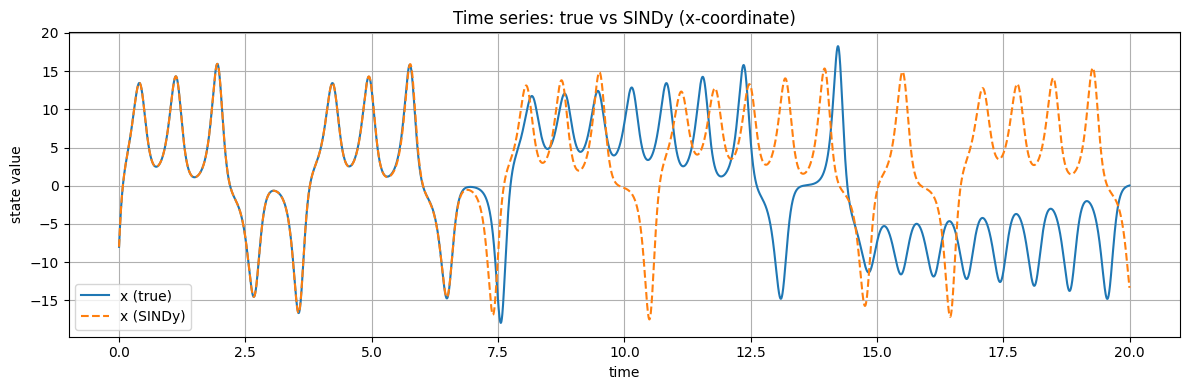

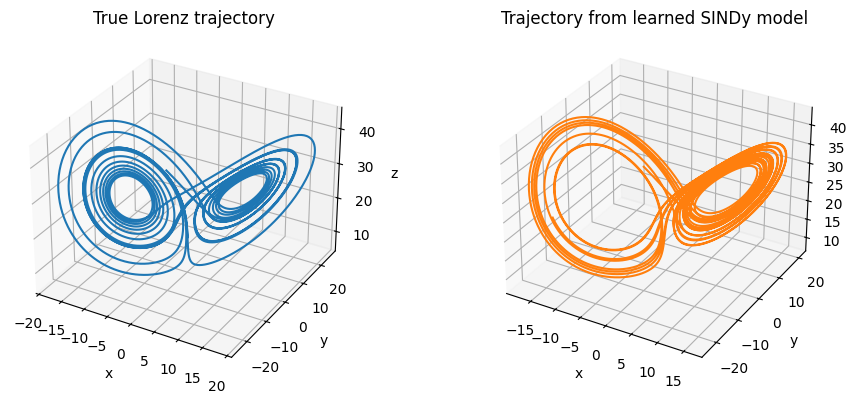

In [6]:



# 1. Define the Lorenz system and generate training data

beta = [10.0, 28.0, 8.0 / 3.0]  # (sigma, rho, beta_param)


def lorenz(t, x):
    """Lorenz right-hand side."""
    sigma, rho, b = beta
    return [
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - b * x[2],
    ]


# Time grid for simulation
t_final = 20.0
dt = 0.002
t_eval = np.arange(0, t_final, dt)

# Initial condition
x0 = [-8.0, 8.0, 27.0]

sol = solve_ivp(lorenz, (0, t_final), x0, t_eval=t_eval, rtol=1e-12, atol=1e-12)

X = sol.y.T  # shape (nt, 3) : rows are time, columns are (x, y, z)
t = sol.t

print("Data shape X:", X.shape)


# 2. Use PySINDy for differentiation and feature library


# Numerical differentiation (finite differences)
diff = ps.FiniteDifference(order=2)
dXdt = diff._differentiate(X, t)  # shape (nt, 3)

# Polynomial library Θ(X) (up to degree 3)
lib = ps.PolynomialLibrary(degree=3)
Theta = lib.fit_transform(X)  # shape (nt, n_features)
feature_names = lib.get_feature_names(["x", "y", "z"])

print("Theta shape:", Theta.shape)
print("Number of features:", len(feature_names))



# 3.Sequential Thresholded Least Squares (STLSQ)
def sparse_regression(Theta, dXdt, lam=0.05, n_iter=10):
    """
    Solve dXdt ≈ Θ(X) Ξ using sequential thresholded least squares.

    Parameters
    ----------
    Theta  : (m, p) feature matrix
    dXdt   : (m, n) derivatives
    lam    : float, threshold
    n_iter : int, number of STLSQ passes

    Returns
    -------
    Xi : (p, n) coefficient matrix
    """
    # Initial least squares fit
    Xi = np.linalg.lstsq(Theta, dXdt, rcond=None)[0]  # (p, n)

    for _ in range(n_iter):
        small = np.abs(Xi) < lam
        Xi[small] = 0.0

        # Regress each state derivative using only "large" terms
        for k in range(dXdt.shape[1]):  # loop over ẋ, ẏ, ż
            big = ~small[:, k]
            if np.sum(big) == 0:
                continue
            Xi[big, k] = np.linalg.lstsq(
                Theta[:, big], dXdt[:, k], rcond=None
            )[0]
    return Xi


lambda_ = 0.05  # sparsity knob
    
Xi = sparse_regression(Theta, dXdt, lam=lambda_, n_iter=10)

print("Ξ shape:", Xi.shape)


# 4. Print the discovered equations in a readable form

state_names = ["ẋ", "ẏ", "ż"]

for k, state in enumerate(state_names):
    print(f"\n{state} ≈")
    for j, name in enumerate(feature_names):
        coeff = Xi[j, k]
        if np.abs(coeff) > 1e-6:
            print(f"  {coeff:+.4f} * {name}")


# 5. Define SINDy-based RHS using Θ(X) and Ξ (for comparison)

def sindy_rhs(t, x):
    """
    Use the learned model:
        f(x) ≈ Θ(x) Ξ
    where Θ(x) is one-row evaluation of the feature library.
    """
    x_row = x.reshape(1, -1)           # shape (1, 3)
    Theta_x = lib.transform(x_row)     # shape (1, n_features)
    return (Theta_x @ Xi).ravel()      # shape (3,)


# Integrate the learned SINDy model from the same initial condition
sol_sindy = solve_ivp(
    sindy_rhs,
    (0, t_final),
    x0,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-10,
)

X_sindy = sol_sindy.y.T


# 6. PLOTS
plt.figure(figsize=(12, 4))
plt.plot(t, X[:, 0], label="x (true)")
plt.plot(t, X_sindy[:, 0], "--", label="x (SINDy)")
plt.xlabel("time")
plt.ylabel("state value")
plt.title("Time series: true vs SINDy (x-coordinate)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3D trajectory comparison
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(X[:, 0], X[:, 1], X[:, 2])
ax1.set_title("True Lorenz trajectory")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(X_sindy[:, 0], X_sindy[:, 1], X_sindy[:, 2], color="C1")
ax2.set_title("Trajectory from learned SINDy model")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")

plt.tight_layout()
plt.show()
